In [15]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import geopandas as gpd
from adjustText import adjust_text

# use Arial
try: 
    font_path = '/home/emil/.fonts/ARIAL.TTF'  # Your font path goes here
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = prop.get_name()
except:
    print('Arial font not found, using default')

wd = os.path.abspath(os.getcwd()).removesuffix('Code/accSpecPCM')
figdir = wd + 'Figures/'

np.random.seed(42)

fig_sizes = (4.5, 3)

colors = [(r/0xff, g/0xff, b/0xff) for r,g,b in [(0x67, 0x19, 0x70), (0xee, 0x96, 0x4b), 
 (0xb6,0xd0, 0x94), (0x66, 0x00, 0x00), (0xab, 0x81, 0xcd), (0x00, 0x6d, 0x6f),
 (0xe5, 0x62, 0x5e), (0xba, 0xde, 0xfc), (0x87, 0x8e, 0x99), (0x29, 0x70, 0x45),
 (0xff, 0xbf, 0xa0)]]

### Code to extract the predicted chloroplast-targeted genes into their own .fasta files

In [2]:
# set the following paths and functions
# fasta files in fasta_dir are expected to be named {acc}.faa
# fasta file headers are expected to contain the protein ID as their first word after the initial >

dd = wd + 'Data/analysis/accSpecPCM/'
fasta_dir = dd + '00_fastas/' # dir containing protein fasta files with all proteins of the respective accession
chloro_fasta_dir = dd + '02_chloroplast_fastas/' # dir contains protein fasta files containing chloroplast proteins

def localizer_file(accession):
    return dd + '01_loc_data/' + accession + '.localizer.out'

def targetp_file(accession):
    return dd + '01_loc_data/' + accession + '_summary.targetp2'

def tppred_file(accession):
    return dd + '01_loc_data/' + accession + '.tppred.out'

In [3]:
# Functions to parse the different outputs;
# will return lists of genes predicted for the provided compartment
def parse_toolPred_deeploc(fpath, all_genes, comp = 'Plastid'):

    # parse and subset gene set
    df = pd.read_csv(fpath, index_col = 0)
    intersect_genes = df.index.intersection(all_genes)
    df = df.loc[intersect_genes]
    if len(intersect_genes) != len(all_genes):
        print(f'Found {len(intersect_genes)} of {len(all_genes)} given genes')

    # Use the prediction that the tool outputs directly
    return df['Localizations'].str.split('|').apply(lambda ls: comp in ls) \
        .loc[lambda curr_df: curr_df].index.to_list()


def parse_toolPred_localizer(fpath, all_genes, comp = 'Chloroplast'):

    # get length of comments
    with open(fpath, 'r') as file:
        found_comments = False
        for i, line in enumerate(file):
            if not found_comments and line.startswith('#'):
                found_comments = True
            if found_comments and not line.startswith('#'):
                break

    # parse and subset genes
    df = pd.read_csv(fpath, sep='\t', skiprows = i)
    df.columns = [col.strip() for col in df]
    df['Identifier'] = df['Identifier'].apply(lambda s: s.split()[0])
    df = df.set_index('Identifier')

    intersect_genes = df.index.intersection(all_genes)
    df = df.loc[intersect_genes]
    if len(intersect_genes) != len(all_genes):
        print(f'Found {len(intersect_genes)} of {len(all_genes)} given genes')

    # find predicted genes
    if comp in df.columns:
        return df.loc[df[comp].apply(lambda s: s.strip()) != '-'].index.to_list()
    print('Did not find specified compartment in the columns. Options are:')
    print(', '.join(df.columns.to_list()))


def parse_toolPred_targetP(fpath, all_genes, comp = 'Chloroplast'):

    # get valid compartments
    if comp in ['Plastid', 'Chloroplast']:
        comps = ['cTP', 'luTP']
    elif comp in ['Mitochondrion', 'Mitochondrium']:
        comps = ['mTP']
    else:
        print('Specified compartment is not valid for this dataset')
        return     

    # get length of comments
    with open(fpath, 'r') as file:
        found_comments = False
        for i, line in enumerate(file):
            if not found_comments and line.startswith('#'):
                found_comments = True
            if found_comments and not line.startswith('#'):
                break

    # parse and subset genes
    df = pd.read_csv(fpath, sep='\t', skiprows = i, header = None)
    df.columns = 'ID	Prediction	noTP	SP	mTP	cTP	luTP	CS_Position'.split()
    df = df.set_index('ID')

    intersect_genes = df.index.intersection(all_genes)
    df = df.loc[intersect_genes]
    if len(intersect_genes) != len(all_genes):
        print(f'Found {len(intersect_genes)} of {len(all_genes)} given genes')

    # find predicted genes
    return df['Prediction'].apply(lambda s: s.strip() in comps).loc[lambda s: s].index.to_list()


def parse_toolPred_bacello(fpath, all_genes, comp = 'Chloroplast'):
    comp_options = ['Chloroplast', 'Cytoplasm', 'Nucleus', 'Extracellular', 'Mitochondrion']
    if comp not in comp_options:
        print('comp not precicted by Bacello. Options are:')
        print(', '.join(comp_options))
        return

    # parse and subset genes
    df = pd.read_csv(fpath, sep='\t', header = None)
    df.columns = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
    df = df.set_index('seqid')

    intersect_genes = df.index.intersection(all_genes)
    df = df.loc[intersect_genes]
    if len(intersect_genes) != len(all_genes):
        print(f'Found {len(intersect_genes)} of {len(all_genes)} given genes')

    # find predicted genes
    return df#['type'].apply(lambda s: s.strip() == comp).loc[lambda s: s].index.to_list()


def parse_toolPred_tppred(fpath, all_genes, comp = 'Chloroplast'):
    if comp not in ['Chloroplast', 'Mitochondrion']:
        print('comp not predictable with TPPred!')
        return

    # parse and subset genes
    df = pd.read_csv(fpath, sep='\t', skiprows = 1, header = None)
    df.columns = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
    df = df.set_index('seqid')

    intersect_genes = df.index.intersection(all_genes)
    df = df.loc[intersect_genes]
    if len(intersect_genes) != len(all_genes):
        print(f'Found {len(intersect_genes)} of {len(all_genes)} given genes')

    # parse which compartment is predicted, and filter
    df['loc'] = df['attributes'].apply(lambda x: 'Mitochondrion' if 'Mitochondrion' in x else ('Chloroplast' if 'Chloroplast' in x else 'Error'))
    df = df.loc[df['type'] == 'Transit peptide', ['score', 'loc']]

    # find predicted genes
    return df.loc[df['loc'] == comp].index.to_list()

def find_gene_chrom(gene):
    return gene.split('_')[-1][0].upper()

In [4]:
# Number of tools that have to predict that a protein is targeted
# to the chloroplast in order for it to be accepted
min_tools_pred = 2

print('Gather genes present in the accessions ...')
pred_genes = {}
for fname in os.listdir(dd + '00_fastas/'):
    if fname.endswith('.faa'):
        curr_acc = fname.removesuffix('.faa')
        with open(dd + '00_fastas/' + fname, 'r') as file:
            curr_genes = [line.removeprefix('>').split()[0] for line in file if line.startswith('>')]
        if len(set(curr_genes)) != len(curr_genes):
            print('Duplicated genes in acc', curr_acc)
        pred_genes[curr_acc] = curr_genes

print('Parsing predictions...')
accepted_genes = {}
for acc in pred_genes:
    localizer_ls = parse_toolPred_localizer(localizer_file(acc), pred_genes[acc], comp = 'Chloroplast')
    targetp_ls = parse_toolPred_targetP(targetp_file(acc), pred_genes[acc], comp = 'Chloroplast')
    tppred_ls = parse_toolPred_tppred(tppred_file(acc), pred_genes[acc], comp = 'Chloroplast')

    # generate consensus list of proteins predicted to be chloroplast-targeted by at least 2 tools
    pred_by = {}  # str: int, maps proteins to number of predictors that predicted chloroplast
    for ls in [localizer_ls, targetp_ls, tppred_ls]:
        for prot in ls:
            pred_by[prot] = pred_by.get(prot, 0) + 1
    
    # start with all chloroplast-encoded proteins
    chloro_prots = {prot for prot in pred_genes[acc] if find_gene_chrom(prot) == 'C'}
    # then accept all that are predicted targeted
    for prot in pred_by:
        if pred_by[prot] >= min_tools_pred:
            chloro_prots.add(prot)

    accepted_genes[acc] = chloro_prots  

Gather genes present in the accessions ...
Parsing predictions...


In [5]:
print('Copying chloroplast-targeted proteins to their own fasta file')
if not os.path.exists(chloro_fasta_dir):
    os.makedirs(chloro_fasta_dir)

for acc in accepted_genes:
    with open(fasta_dir + acc + '.faa', 'r') as in_file:
        with open(chloro_fasta_dir + acc + '.faa', 'w') as out_file:
            copy_curr = False
            for line in in_file:
                if line.startswith('>'):
                    curr_gene = line.removeprefix('>').split()[0]
                    copy_curr = curr_gene in accepted_genes[acc]
                
                if copy_curr:
                    out_file.write(line)

Copying chloroplast-targeted proteins to their own fasta file


### Run DIAMOND with the blast.sh in the Code/accSpecPCM folder

### Then, create accession-specific models with the araAccsModelCreation.m script

### Plotting

In [6]:
rxn_pav = pd.read_csv(dd + '05_comparison_data/rxnPav.csv', index_col=0)
subs_pav = pd.read_csv(dd + '05_comparison_data/subsPav.csv', index_col=0)
model_data = pd.read_csv(dd + '05_comparison_data/modelData.csv')

figscale = 2/3
figsize = (4.5* figscale, 2 * figscale)

### geographic distribution

/tmp/ipykernel_194843/2590917194.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


10 [-0.88383278  0.73235229]
11 [0.20223002 0.41614516]
12 [-0.95883101  0.9398197 ]


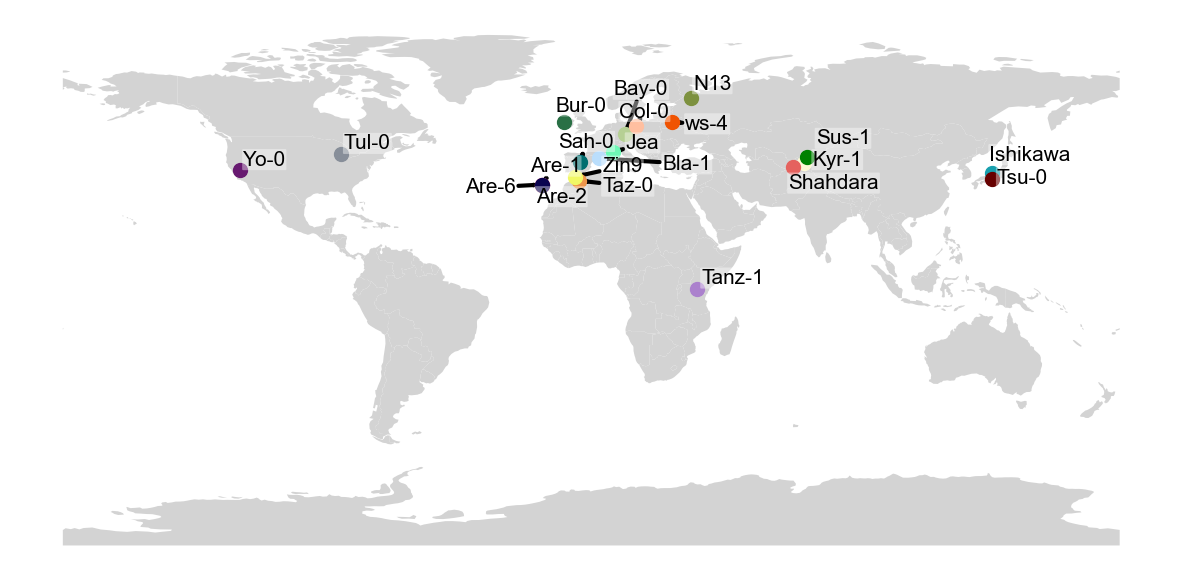

In [10]:
acc_colors = {'Bay_0': (0.7137254901960784, 0.8156862745098039, 0.5803921568627451),
 'Tsu_0': (0.4, 0.0, 0.0),
 'Tanz_1': (0.6705882352941176, 0.5058823529411764, 0.803921568627451),
 'Sah_0': (0.0, 0.42745098039215684, 0.43529411764705883),
 'Yo_0': (0.403921568627451, 0.09803921568627451, 0.4392156862745098),
 'Bla_1': (0.7294117647058823, 0.8705882352941177, 0.9882352941176471),
 'Taz_0': (0.9333333333333333, 0.5882352941176471, 0.29411764705882354),
 'Tul_0': (0.5294117647058824, 0.5568627450980392, 0.6),
 'Bur_0': (0.1607843137254902, 0.4392156862745098, 0.27058823529411763),
 'Shahdara': (0.8980392156862745, 0.3843137254901961, 0.3686274509803922),
 'Col_0': (1.0, 0.7490196078431373, 0.6274509803921569),
 'Ishikawa': (0.09420883275304903, 0.6291104599922431, 0.6824609344562551),
 'Jea': (0.43295705596247447, 0.977306284453068, 0.7149742169030798),
 'Are_2': (0.7295717741268839, 0.13649403034894358, 0.19796436224306502),
 'Kyr_1': (0.9959886544597308, 0.9734492909139295, 0.8321033597324019),
 'Zin9': (0.9464595039109757, 0.9743493484289852, 0.39480811242266334),
 'Sus_1': (0.0, 0.5, 0.0),
 'Are_1': (0.9323878060021565, 0.6217871261248432, 0.9714098047064589),
 'N13': (0.4893595127800914, 0.568091895766057, 0.24836263274487747),
 'Are_6': (0.03832082855633301, 0.01759986003474967, 0.3126032308147183),
 'ws_4': (0.9429869673601893, 0.32719541527657214, 0.0027378078024445918)}

# read geos
geos = pd.read_csv(wd + 'Data/analysis/accSpecPCM/05_comparison_data/geos.csv')

# plot some values on world map
# ignore FutureWarning and keep geopandas pinned to 0.14.4
countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
countries.plot(color="lightgrey", figsize=(15,15))

texts = []
text_props = dict(boxstyle='round', facecolor='white', alpha=0.4, linewidth=0, pad = 0.05)
for i, (acc, lon, lat) in enumerate(zip(geos['name'], geos['longitude'], geos['latitude'])):
    plt.plot(lon, lat, 'o', c = acc_colors[acc.replace('-', '_')], markersize=10)#, alpha = 0.6)
    texts.append(plt.text(lon, lat, geos['name'].iloc[i], fontsize=15, bbox = text_props, zorder = 1000))

adjust_text(texts, expand=(1.1, 1.1), min_arrow_len = 10,
            arrowprops=dict(arrowstyle='->', lw = 3, color='k', alpha=1.))
plt.axis('off')
plt.savefig(f'{figdir}acc_world_map.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

### general model stats

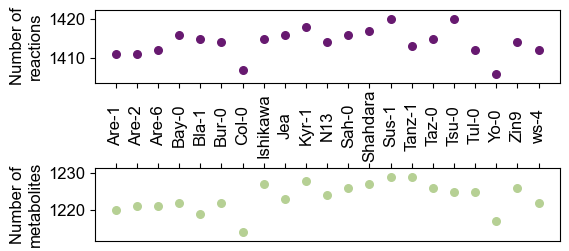

In [11]:
plt.rcParams['font.size'] = 12
fig, axes = plt.subplots(3, 1, figsize=(6, 3), sharex=True, gridspec_kw={'height_ratios': [1, 0.8, 1]})

def widen_lims(lims):
    lower, upper = lims
    range = upper - lower
    return (lower - 0.1 * range, upper + 0.1 * range)

# Plot nRxns
axes[0].scatter(list(range(model_data.shape[0])), model_data['nRxns'], color=colors[0], s=30)
axes[0].set_ylabel('Number of\nreactions')
axes[0].set_xticks(list(range(model_data.shape[0])))
axes[0].set_xticklabels(model_data['model_name'], rotation=90, ha='center', va='top', snap=False)
axes[0].tick_params(axis='x', which='both', bottom=True, labelbottom=False)
axes[0].set_ylim(widen_lims(axes[0].get_ylim()))

axes[1].axis('off')  # Hide the middle subplot
for model_name, x in zip(model_data['model_name'], range(model_data.shape[0])):
    axes[1].text(x, 0.5, model_name, ha='center', va='center', rotation=90)

# Plot nMets
axes[2].scatter(list(range(model_data.shape[0])), model_data['nMets'], color=colors[2], s=30)
axes[2].set_ylabel('Number of\nmetabolites')
axes[2].set_xticks(list(range(model_data.shape[0])))
axes[2].set_xticklabels(model_data['model_name'], rotation=90, ha='center', va='bottom')
axes[2].tick_params(axis='x', which='both', bottom=False, labelbottom=False, top=True)
axes[2].set_ylim(widen_lims(axes[2].get_ylim()))
# put x tick labels in the middle of the two subplots


# Shared xlabel in the middle
#plt.tight_layout()
plt.savefig(f'{figdir}acc_models_stats.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [12]:
model_data['nRxns'].max()

1420

### rxn PAV

In [13]:
print('Number of reactions shared by all accession models:', rxn_pav.all().sum())
print('Number of reactions in any accession model:', rxn_pav.any().sum())
print('Percentage of core reactions:', rxn_pav.all().sum() / rxn_pav.any().sum())

Number of reactions shared by all accession models: 1369
Number of reactions in any accession model: 1464
Percentage of core reactions: 0.9351092896174863


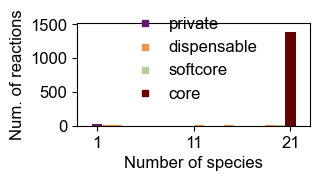

In [28]:
fig, ax = plt.subplots(figsize=figsize)

range_per_plot = 30

# get data (in rxn_pav, the first bin is 0 because some rxns are in no model; this cannot happen with genes)
counts, bins = np.histogram(rxn_pav.mean() * rxn_pav.shape[0], bins = rxn_pav.sum().nunique())
# exclude that bin because it makes no sense in this framework)
counts = counts[1:]
bins = bins[1:]
poss = np.linspace(1, bins[-1], len(bins) - 1)
heights = counts
breakpoint_mid = int(np.ceil(len(counts) * 0.9))
upper_limit1 = counts.max() * 1.1

# plot each subplot
box1 = ax.bar(poss[0], heights[0], width=poss[1]-poss[0], color=colors[0], label='private')
box2 = ax.bar(poss[1:breakpoint_mid], heights[1:breakpoint_mid], width=poss[1]-poss[0], color=colors[1], label='dispensable')
box3 = ax.bar(poss[breakpoint_mid:-1], heights[breakpoint_mid:-1], width=poss[1]-poss[0], color=colors[2], label='softcore')
box4 = ax.bar(poss[-1:], heights[-1:], width=poss[1]-poss[0], color=colors[3], label='core')
draw_legend = True
if draw_legend:
    ax.legend(bbox_to_anchor=(0.84, 0.09), frameon=False, 
            handles = [mpl.lines.Line2D([], [], marker = 's', linewidth=0, markersize = 4,
                                        color=colors[i])#box.get_children()[0].get_facecolor())
                                        for i, box in enumerate([box1, box2, box3, box4])],
            labels=[box.get_label() for box in [box1, box2, box3, box4]], 
            handletextpad = 0.4, handleheight = 0.4)
ax.set_ylim(0, upper_limit1)
ax.set_xlabel('Number of species')
ax.set_ylabel('Num. of reactions')
ax.set_yticks([500 * (i) for i in range(4)])
xlim = ax.get_xlim()
ax.set_xticks(ax.get_xticks() + 1)
ax.set_xlim(poss[0] - 2, poss[-1] + 2)

# output plot
plt.savefig(figdir + 'panreactome_accs_hist.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

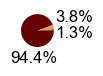

1.3
3.8
0.5
94.4


In [29]:
# pie chart
plt.figure(figsize = [val/2.5 for val in figsize])
private = counts[0]
dispensable = sum(counts[1:breakpoint_mid])
softcore = sum(counts[breakpoint_mid:-1])
core = counts[-1]
tot = private + dispensable + softcore + core
patches, texts = plt.pie([x for x in [private, dispensable, softcore, core]], colors = colors,
        labels=[f'{round(share/tot*100, 1)}%' for share in [private, dispensable, softcore, core]])
texts[3].set_y(-1.7)
texts[3].set_x(1.2)
texts[2].set_visible(False)
texts[1].set_y(0.8)
texts[0].set_y(-0.2)
plt.savefig(figdir + 'accs_panreactome_pie.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

tot = private + dispensable + softcore + core
print(round(private/tot*100, 1))
print(round(dispensable/tot*100, 1))
print(round(softcore/tot*100, 1))
print(round(core/tot*100, 1))